# EDA

In [1]:
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
## connecting to database 

load_dotenv(dotenv_path="../.env")

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [3]:

query = """
SELECT
    c.customer_id, c.gender, c.senior_citizen, c.partner, c.dependents, c.tenure,
    s.phone_service, s.multiple_lines, s.internet_service, s.online_security,
    s.online_backup, s.device_protection, s.tech_support, s.streaming_tv, s.streaming_movies,
    b.contract, b.paperless_billing, b.payment_method, b.monthly_charges, b.total_charges,
    ch.churn
FROM customers c
JOIN services s ON c.customer_id = s.customer_id
JOIN billing b ON c.customer_id = b.customer_id
JOIN churn_status ch ON c.customer_id = ch.customer_id;
"""

df = pd.read_sql(query, engine)
print(df.shape)
df.head()

(7043, 21)


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,False,True,False,1,False,No phone service,DSL,No,...,No,No,No,No,Month-to-month,True,Electronic check,29.85,29.85,False
1,5575-GNVDE,Male,False,False,False,34,True,No,DSL,Yes,...,Yes,No,No,No,One year,False,Mailed check,56.95,1889.50,False
2,3668-QPYBK,Male,False,False,False,2,True,No,DSL,Yes,...,No,No,No,No,Month-to-month,True,Mailed check,53.85,108.15,True
3,7795-CFOCW,Male,False,False,False,45,False,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,False,Bank transfer (automatic),42.30,1840.75,False
4,9237-HQITU,Female,False,False,False,2,True,No,Fiber optic,No,...,No,No,No,No,Month-to-month,True,Electronic check,70.70,151.65,True


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   bool   
 3   partner            7043 non-null   bool   
 4   dependents         7043 non-null   bool   
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   bool   
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streaming_tv       7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract           7043 non-null   object 
 16  paperless_billing  7043 

In [6]:
df.isnull().sum()

customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
phone_service        0
multiple_lines       0
internet_service     0
online_security      0
online_backup        0
device_protection    0
tech_support         0
streaming_tv         0
streaming_movies     0
contract             0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
churn                0
dtype: int64

In [7]:
df.describe()

,tenure,monthly_charges,total_charges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


# Lets begain Univeriate analysis 

## For numerical Features

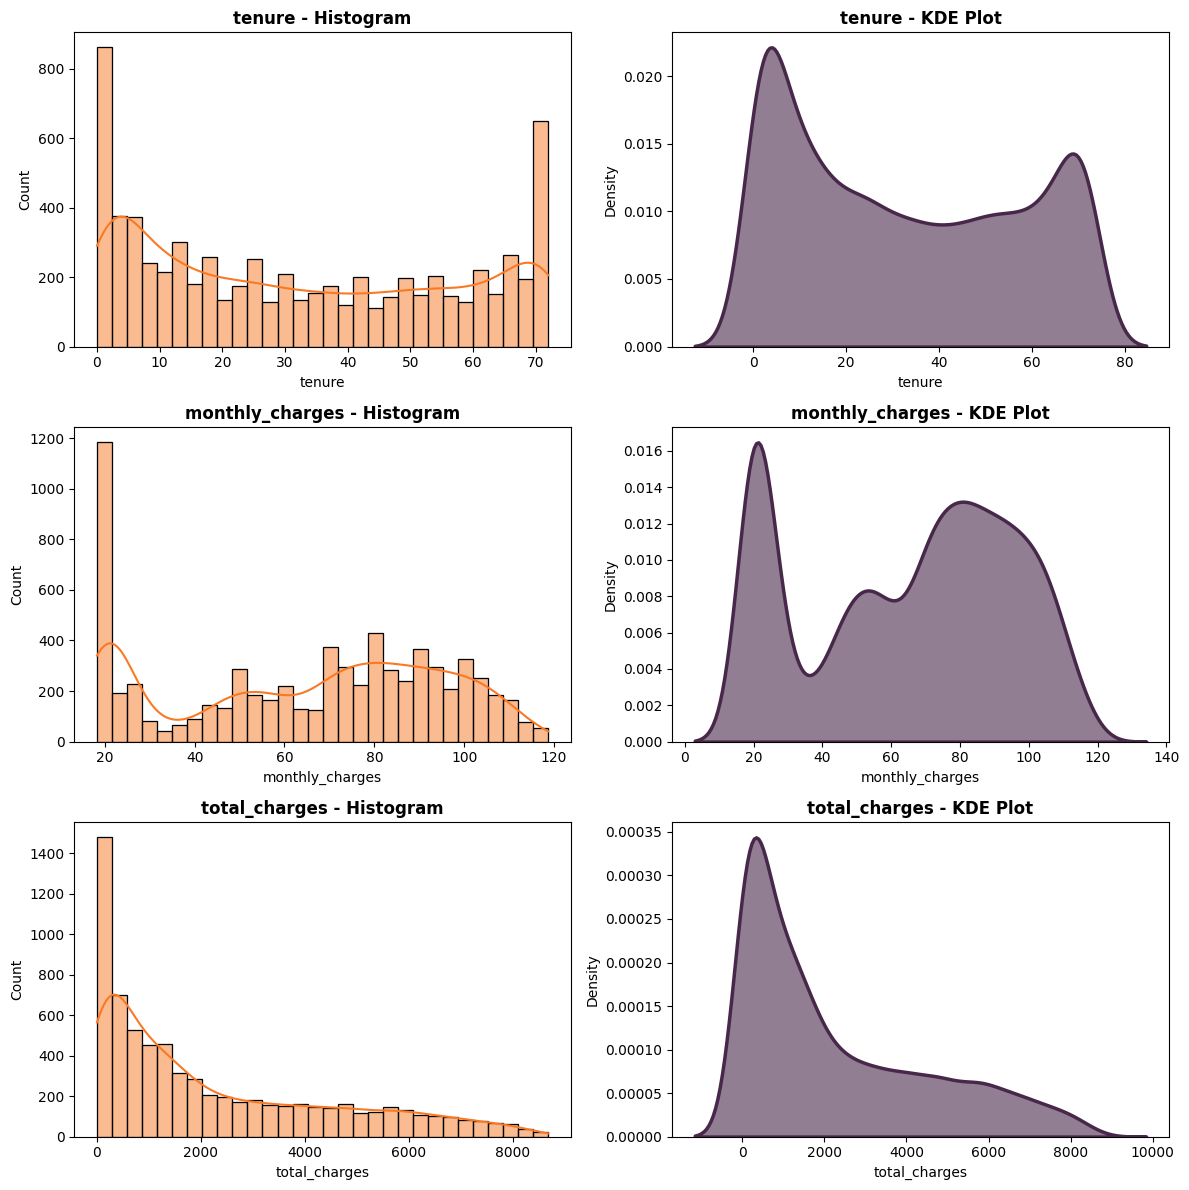

In [13]:
#Create 3x2 grid figure
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# Define the custom color dictionary required by your code
colors = {
    "orange": "#f97924",
    "pink": "#ffc6d9",
    "cream": "#fff7ae",
    "dark_purple": "#48284a",
    "mauve": "#916c80",
}

cols = ["tenure", "monthly_charges", "total_charges"]

for i, col in enumerate(cols):
    # Left column (Histogram + KDE line)
    sns.histplot(
        df[col],
        kde=True,
        color=colors["orange"],
        bins=30,
        ax=axes[i, 0],
    )
    axes[i, 0].set_title(f"{col} - Histogram", fontweight="bold")

    # Right column (KDE Plot with filled area)
    sns.kdeplot(
        df[col],
        ax=axes[i, 1],
        fill=True,
        alpha=0.6,
        linewidth=2.5,
        color=colors["dark_purple"]
    )
    axes[i, 1].set_title(f"{col} - KDE Plot", fontweight="bold")

plt.tight_layout()
plt.show()

## For Cataogarical Features

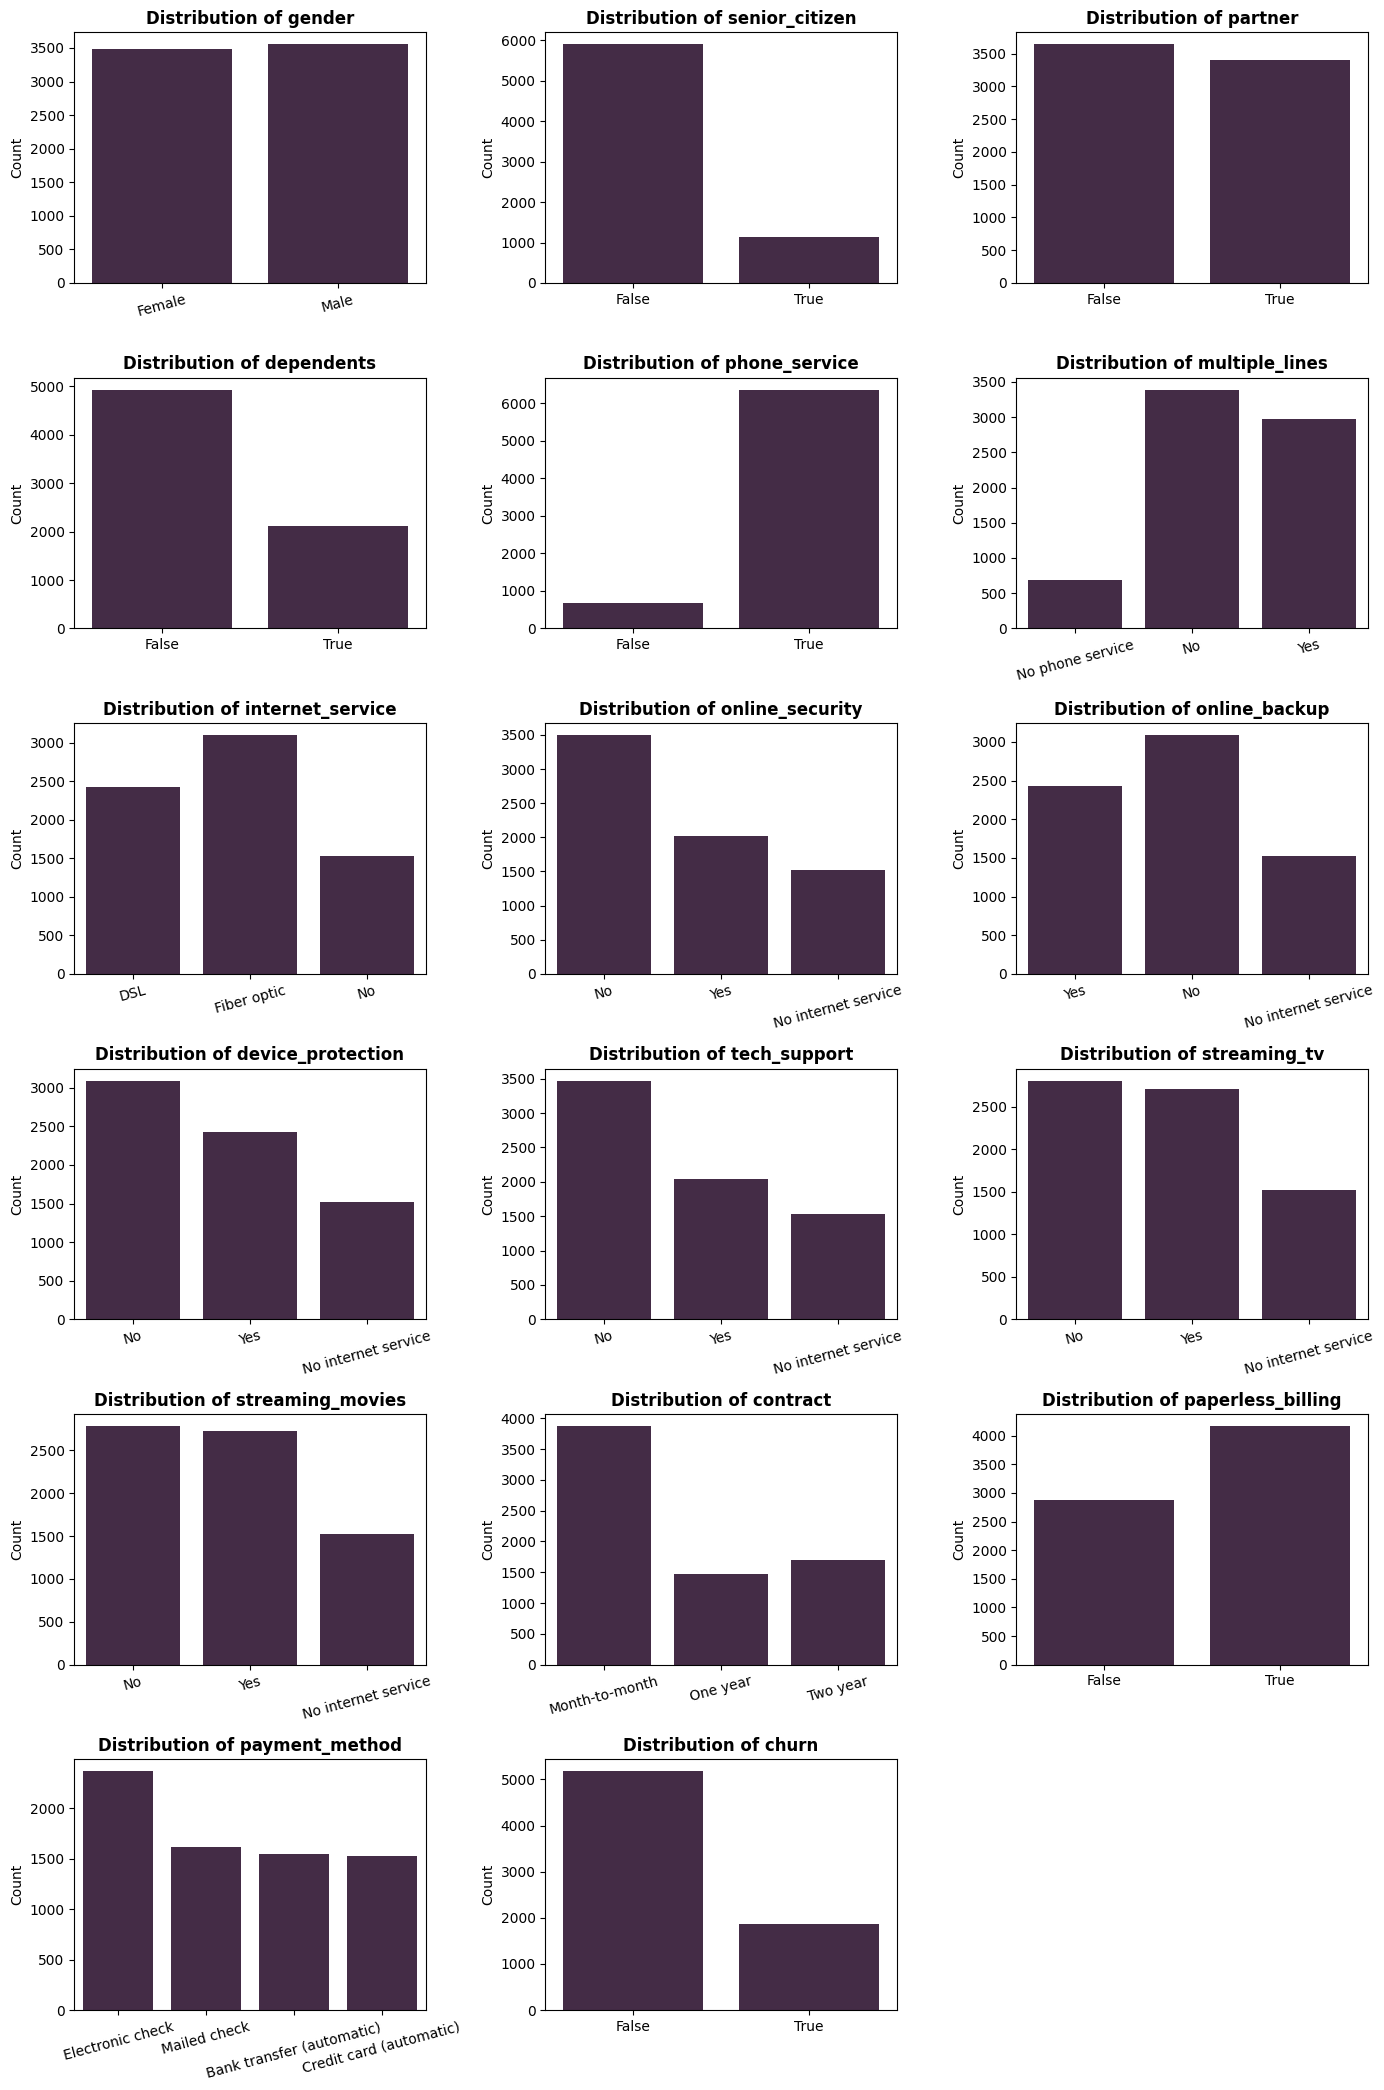

In [16]:
import math

# 1. Select all categorical columns (excluding customer_id if present)
cat_cols = df.select_dtypes(include=["object", "bool"]).columns.tolist()
if "customer_id" in cat_cols:
    cat_cols.remove("customer_id")

# 2. Calculate grid dimensions (2 columns wide)
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

# 3. Create grid figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()  # Flatten 2D array to easily iterate with single index

# 4. Plot each categorical feature
for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df,
        x=col,
        ax=axes[i],
        color=colors["dark_purple"],
        
    )
    axes[i].set_title(f"Distribution of {col}", fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

    # Rotate labels if categories are long (e.g., payment_method)
    if df[col].nunique() > 2 or df[col].dtype == "object":
        axes[i].tick_params(axis="x", rotation=15)

# Hide any remaining empty subplots if the total count of features is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Univariate analysis — observations

**Numeric features**
- `tenure` is bimodal — a large cluster near 0 months and another near 70 months,
  with fewer customers in between. The customer base splits into two groups:
  recent joiners and long-term loyal customers, rather than a smooth spread.
- `monthly_charges` is also bimodal, peaking near 20 and again near 80-90.
  This likely reflects two pricing segments: phone-only customers (cheap,
  `~20`) versus internet + streaming bundle customers (`~80-100`).
- `total_charges` is heavily right-skewed, with most customers clustered near
  0 and a long tail out to `~8000`. This is expected, since `total_charges`
  accumulates over `tenure` — new customers haven't had time to build up a
  high total yet.

**Categorical features**
- `churn` confirms the known 26% / 74% imbalance, which rules out accuracy
  as a usable metric going forward.
- `senior_citizen` (`~84% `False) and `phone_service` (`~90%` True) are both
  heavily imbalanced. Features this skewed tend to carry little predictive
  power on their own, since there's barely any variation to learn from.
- `online_security`, `online_backup`, `device_protection`, `tech_support`,
  `streaming_tv`, and `streaming_movies` all share a third category,
  "No internet service," which isn't really an answer to the question, it's
  a different population (customers with no internet at all) collapsed into
  the same column. Worth handling carefully during encoding in the next
  notebook, rather than treating it as a normal "No."
- `gender` and `partner` are both close to a 50/50 split, so neither looks
  like a strong candidate for a predictive signal on its own.
- `contract` is dominated by month-to-month customers (`~55%` of the base),
  consistent with the churn-rate gap already found in the SQL analysis.

**What this sets up:** the bimodal shape of `tenure` and `monthly_charges`
suggests the customer base isn't one uniform group, it's at least two
distinct segments. The next step is bivariate analysis — checking churn rate
against each feature individually — to see which of these splits actually
line up with who leaves.

# Bivariate Analysis 

## Numerical Features

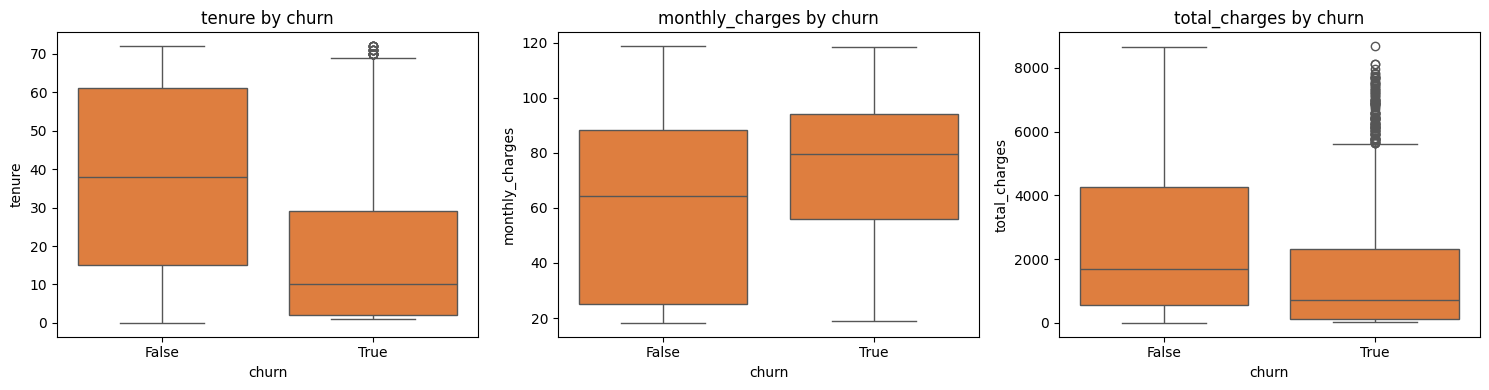

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(["tenure", "monthly_charges", "total_charges"]):
    sns.boxplot(data=df, x="churn", y=col, ax=axes[i], color="#f97924")
    axes[i].set_title(f"{col} by churn")
plt.tight_layout()
plt.show()

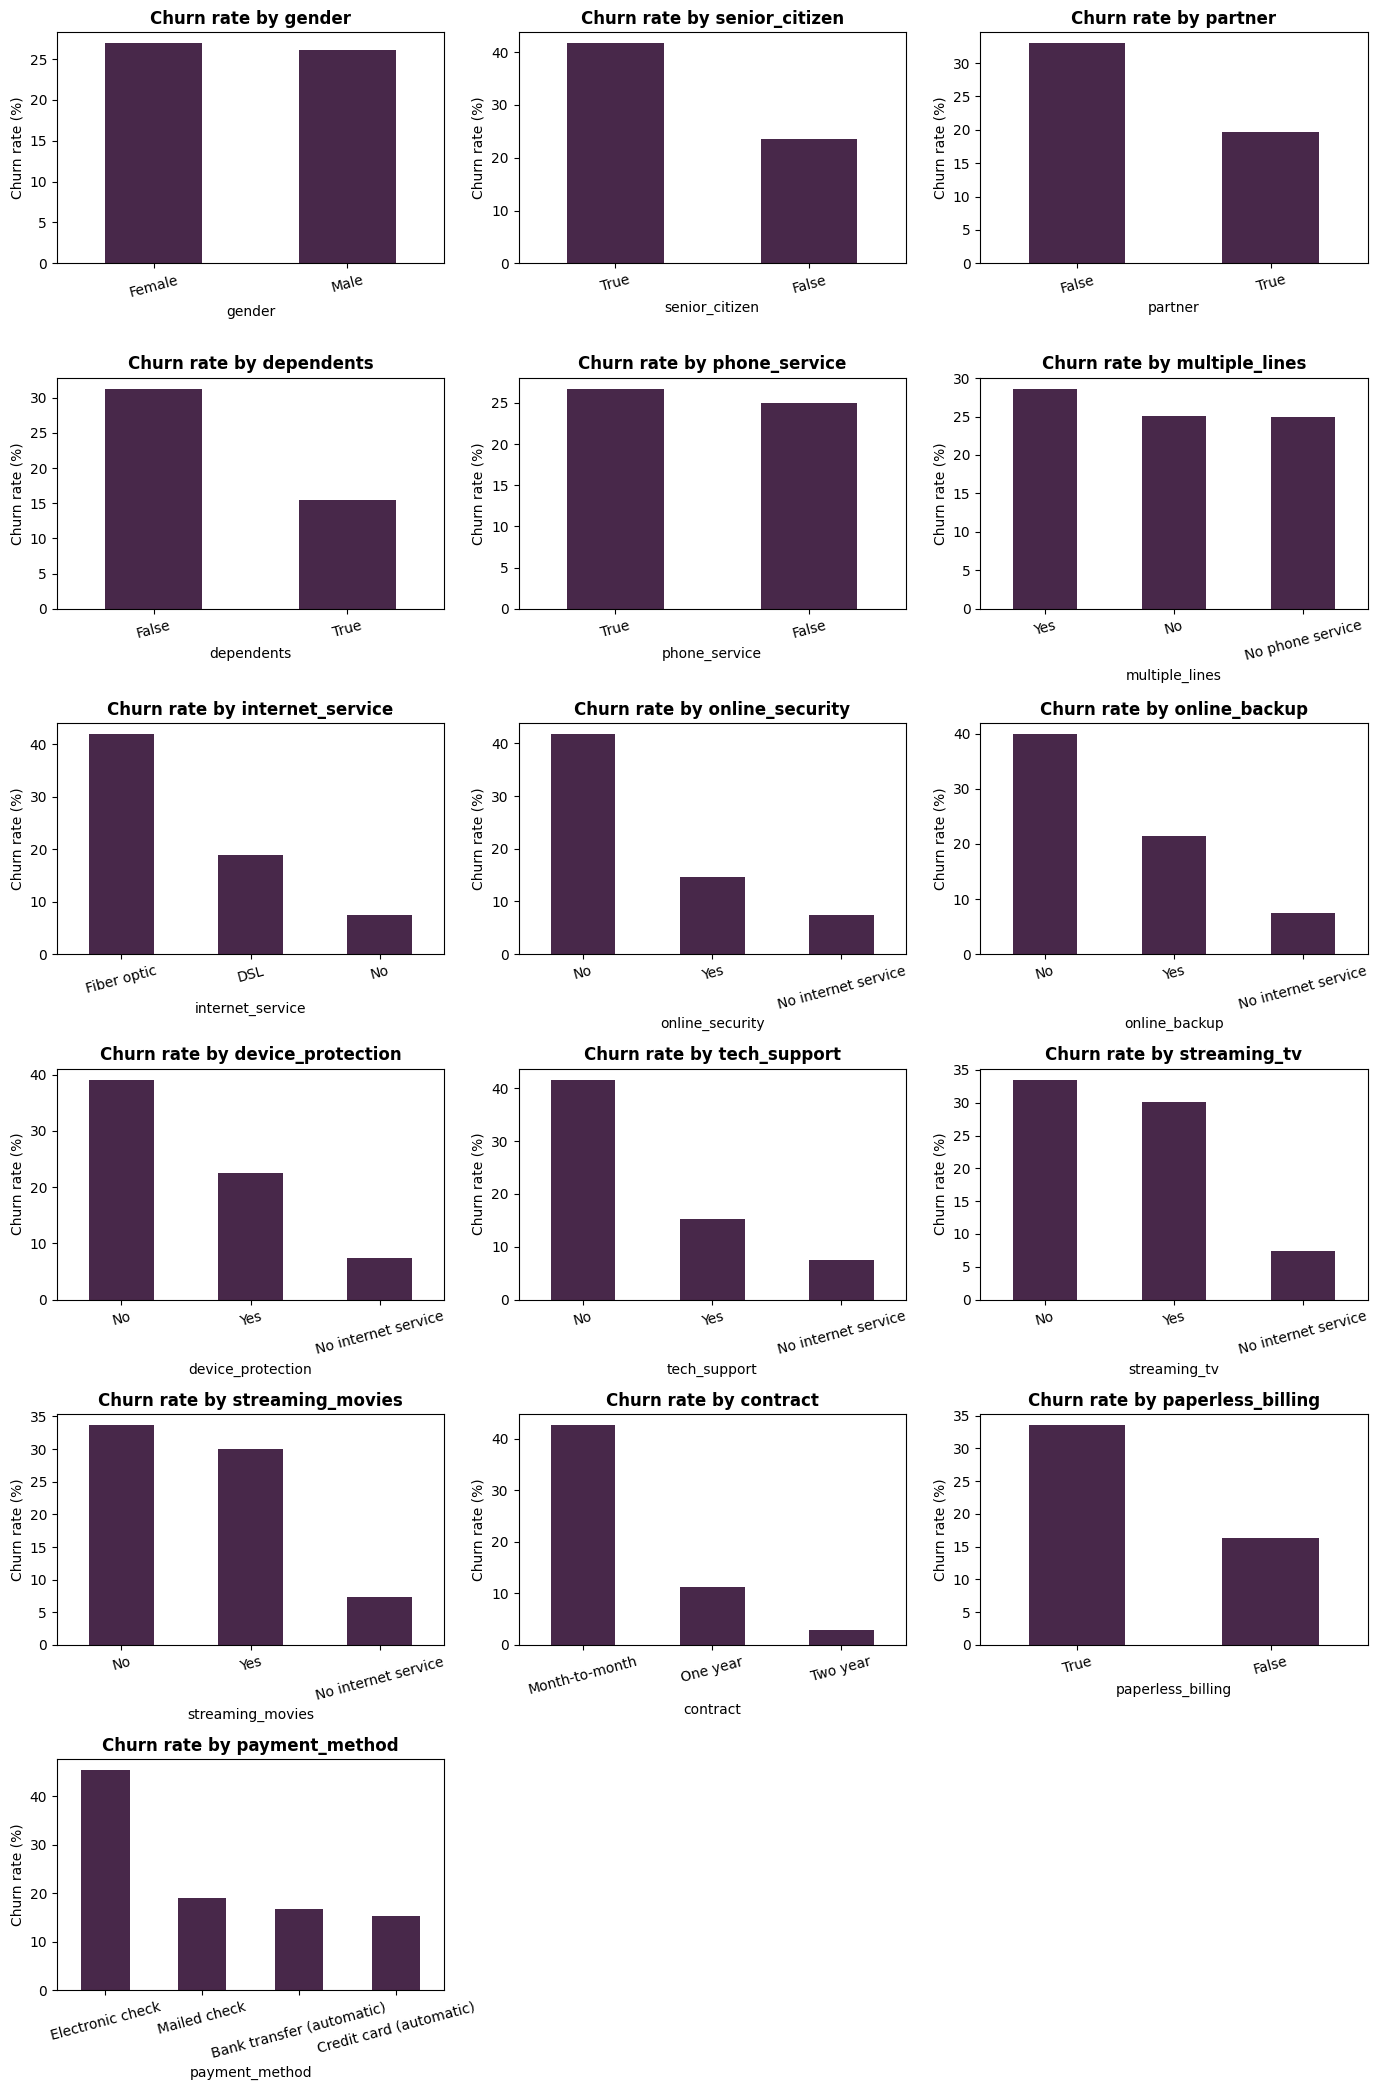

In [19]:
cat_cols = df.select_dtypes(include=["object", "bool"]).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ["customer_id", "churn"]]

n_cols = 3
n_rows = -(-len(cat_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)["churn"].mean().sort_values(ascending=False) * 100
    churn_rate.plot(kind="bar", ax=axes[i], color="#48284a")
    axes[i].set_title(f"Churn rate by {col}", fontweight="bold")
    axes[i].set_ylabel("Churn rate (%)")
    axes[i].tick_params(axis="x", rotation=15)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Multivarite 

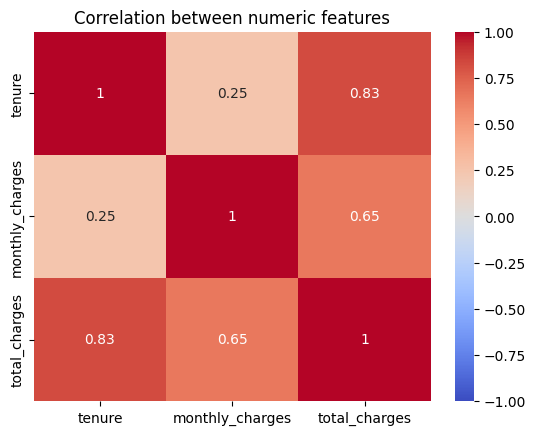

In [20]:
corr = df[["tenure", "monthly_charges", "total_charges"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between numeric features")
plt.show()

## Bivariate & multivariate analysis — observations

**Numeric vs. churn**
- `tenure` shows the clearest separation: churned customers have a much
  lower median tenure (~10 months) than retained customers (~38 months).
- `monthly_charges` is higher among churned customers (median ~80 vs ~65),
  consistent with the SQL finding that churn rises with price.
- `total_charges` is lower among churned customers, but this largely
  reflects their shorter tenure rather than an independent effect.

**Categorical vs. churn**
- Weakest signal: `gender` and `phone_service`, both nearly flat across
  categories (~25-26% either way) — low priority as predictive features.
- Strongest signal: `contract` (month-to-month ~43% vs two-year ~3%) and
  `payment_method` (Electronic check ~45% vs ~15-20% for the other three),
  the two biggest churn-rate gaps in the whole dataset.
- `internet_service` shows a large gap too (Fiber optic ~42% vs DSL ~19%
  vs No internet ~7%), and lines up with the monthly-charges finding —
  fiber customers pay more and churn more.
- Every service add-on (online security, tech support, backup, device
  protection, streaming TV/movies) follows the same pattern: having the
  add-on roughly halves the churn rate compared to not having it, and the
  "No internet service" segment (the same ~1,526 customers throughout)
  churns least of all at a flat 7.4%.

**Correlation**
- `tenure` and `total_charges` are strongly correlated (0.83), and
  `monthly_charges` and `total_charges` are moderately correlated (0.65).
  `total_charges` carries little information beyond what `tenure` and
  `monthly_charges` already provide — a candidate to drop, transform (e.g.
  average charge per month), or leave for the model's feature-importance
  step to resolve, rather than a decision to make blindly here.

**What stands out going into feature engineering:** contract type, payment
method, internet service type, tenure, and the service add-ons are the
strongest candidates for predictive power. Gender and phone service look
close to noise. The `total_charges` redundancy needs an explicit decision
in the next notebook.